# Redes Neuronales Convolucionales (CNN)
| IA 5.2 Computer Vision   
| FCEIA - UNR

En este cuaderno repasamos los conceptos fundamentales de las CNN aplicadas a vision por computadora: arquitectura **backbone-neck-head**, funcionamiento de un backbone convolucional con **ResNet50**, tipos de **datasets** y ejemplos practicos con modelos pre-entrenados.

# Librerias a utilizar

In [57]:
# !pip install torch torchvision

In [1]:
import ssl
import torch
import torch.nn as nn
import torchvision
import torchvision.models as models
import torchvision.transforms as T
from torchvision.models import ResNet50_Weights
import torchvision.datasets as datasets
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request
import io
import os

print(f"PyTorch:      {torch.__version__}")
print(f"Torchvision:  {torchvision.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo:  {device}")


PyTorch:      2.11.0+cu130
Torchvision:  0.26.0+cu130
Dispositivo:  cpu


In [2]:

# --- Helpers para carga robusta de imagenes ---

def descargar_imagen(url, timeout=8):
    """Descarga una imagen. Intenta primero SSL normal, luego sin verificacion."""
    for verify_ssl in [True, False]:
        try:
            if verify_ssl:
                resp = urllib.request.urlopen(url, timeout=timeout)
            else:
                ctx = ssl.create_default_context()
                ctx.check_hostname = False
                ctx.verify_mode = ssl.CERT_NONE
                resp = urllib.request.urlopen(url, timeout=timeout, context=ctx)
            with resp:
                return Image.open(io.BytesIO(resp.read())).convert("RGB")
        except Exception:
            continue
    return None

def imagen_sintetica_escena():
    """Imagen sintetica con estructura (cielo, suelo, sol, objeto) para feature maps informativos."""
    arr = np.zeros((224, 224, 3), dtype=np.uint8)
    for i in range(130):
        t = i / 130
        arr[i, :] = [int(80*t), int(130*t), int(220 - 60*t)]
    arr[130:, :] = [55, 115, 45]
    Y, X = np.ogrid[:224, :224]
    arr[(Y-45)**2 + (X-175)**2 <= 28**2] = [255, 220, 40]
    mask_body = ((Y-145)/35)**2 + ((X-100)/55)**2 <= 1
    mask_head = ((Y-103)/26)**2 + ((X-132)/26)**2 <= 1
    arr[mask_body] = [155, 105, 55]
    arr[mask_head] = [155, 105, 55]
    arr[95:99, 121:125] = [25, 15, 10]
    arr[102:106, 128:133] = [75, 35, 25]
    return Image.fromarray(arr)

def cargar_imagen(ruta_local, url_fallback):
    """Carga imagen: archivo local → descarga internet → imagen sintetica."""
    if os.path.exists(ruta_local):
        print(f"[OK] Imagen local: {ruta_local}")
        return Image.open(ruta_local).convert("RGB")
    img = descargar_imagen(url_fallback)
    if img is not None:
        print(f"[OK] Descargada: {url_fallback}")
        return img
    print("[--] Sin imagen local ni internet → imagen sintetica")
    return imagen_sintetica_escena()

print("\nHelpers listos: cargar_imagen(), descargar_imagen(), imagen_sintetica_escena()")


Helpers listos: cargar_imagen(), descargar_imagen(), imagen_sintetica_escena()


---
# 1. Backbone, Neck y Head — La anatomia de una red de vision

Una red neuronal moderna para vision por computadora se organiza en 3 partes:

**Backbone** (columna vertebral): toma la imagen cruda y extrae caracteristicas. Va de pixels a features abstractas: bordes → texturas → formas → partes de objetos. Es la parte mas costosa computacionalmente.

**Neck** (cuello): opcional, conecta el backbone con la cabeza. Combina features de distintas escalas. Comun en deteccion de objetos (ej: FPN), pero en clasificacion simple generalmente no existe.

**Head** (cabeza): produce la prediccion final segun la tarea:
- **Clasificacion**: ¿que objeto es? (ej: "gato" con 95% de confianza)
- **Deteccion**: ¿donde estan los objetos y que son? (bounding boxes + clase)
- **Segmentacion**: ¿a que clase pertenece cada pixel?

```
Imagen → [BACKBONE] → features → [NECK] → [HEAD] → prediccion
224x224    extraccion    mapas     fusion    clas/det    clase/bbox
```

> En clasificacion simple: Imagen → [BACKBONE] → GlobalAvgPool → [HEAD: FC] → clase

In [4]:
# Cargamos ResNet50 sin pesos para ver solo la arquitectura
modelo = models.resnet50(weights=None)

print("=== ResNet50: Estructura Backbone-Neck-Head ===")
print()
print("[STEM] Entrada 224x224 → reduce a 56x56:")
print(f"  conv1:   {modelo.conv1}")
print(f"  maxpool: {modelo.maxpool}")
print()
print("[BACKBONE] Capas residuales:")
sizes = {1: "56x56", 2: "28x28", 3: "14x14", 4: "7x7"}
for i, layer in enumerate([modelo.layer1, modelo.layer2, modelo.layer3, modelo.layer4], 1):
    out_ch = layer[-1].conv3.out_channels if hasattr(layer[-1], "conv3") else layer[-1].conv2.out_channels
    print(f"  layer{i}: {len(layer)} bloques, {out_ch} canales, {sizes[i]}")
print()
print("[NECK] Global Average Pooling:")
print(f"  avgpool: reduce 7x7 → 1x1 (promedia espacialmente)")
print()
print("[HEAD] Clasificador (ImageNet = 1000 clases):")
print(f"  fc: {modelo.fc}")
print()
total = sum(p.numel() for p in modelo.parameters())
backbone_p = sum(p.numel() for n, p in modelo.named_parameters() if "fc" not in n)
head_p = sum(p.numel() for p in modelo.fc.parameters())
print(f"Total parametros:    {total:>12,}")
print(f"  Backbone+Neck:     {backbone_p:>12,} ({backbone_p/total*100:.1f}%)")
print(f"  Head (fc):         {head_p:>12,} ({head_p/total*100:.1f}%)")

=== ResNet50: Estructura Backbone-Neck-Head ===

[STEM] Entrada 224x224 → reduce a 56x56:
  conv1:   Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  maxpool: MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)

[BACKBONE] Capas residuales:
  layer1: 3 bloques, 256 canales, 56x56
  layer2: 4 bloques, 512 canales, 28x28
  layer3: 6 bloques, 1024 canales, 14x14
  layer4: 3 bloques, 2048 canales, 7x7

[NECK] Global Average Pooling:
  avgpool: reduce 7x7 → 1x1 (promedia espacialmente)

[HEAD] Clasificador (ImageNet = 1000 clases):
  fc: Linear(in_features=2048, out_features=1000, bias=True)

Total parametros:      25,557,032
  Backbone+Neck:       23,508,032 (92.0%)
  Head (fc):            2,049,000 (8.0%)


---
# 2. El Backbone Convolucional — Como funciona

El backbone convolucional aplica repetidamente tres operaciones basicas:

**1. Convolucion**: aplica un filtro (kernel) deslizante sobre la imagen. Cada kernel aprende a detectar un tipo de patron (borde, textura, forma). La red aprende automaticamente los mejores kernels durante el entrenamiento.

**2. Activacion ReLU**: `f(x) = max(0, x)`. Elimina valores negativos e introduce no-linealidad — sin ella, apilar capas no serviria de nada.

**3. Pooling**: reduce la resolucion espacial (alto × ancho) manteniendo lo importante. Hace la red mas eficiente y da invarianza traslacional parcial.

Esquema de transformaciones en ResNet50:
```
Imagen [3, 224, 224]
  → STEM  → [64,  112, 112]
  → layer1 → [256,  56,  56]
  → layer2 → [512,  28,  28]
  → layer3 → [1024, 14,  14]
  → layer4 → [2048,  7,   7]
  → AvgPool → [2048,  1,   1]
  → Flatten → [2048]
  → FC     → [1000]   <- num_clases
```
El numero de canales CRECE (mas features) y el espacio se REDUCE (mas contexto).

[W326 16:21:04.296716282 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W326 16:21:04.298628040 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W326 16:21:04.300621692 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


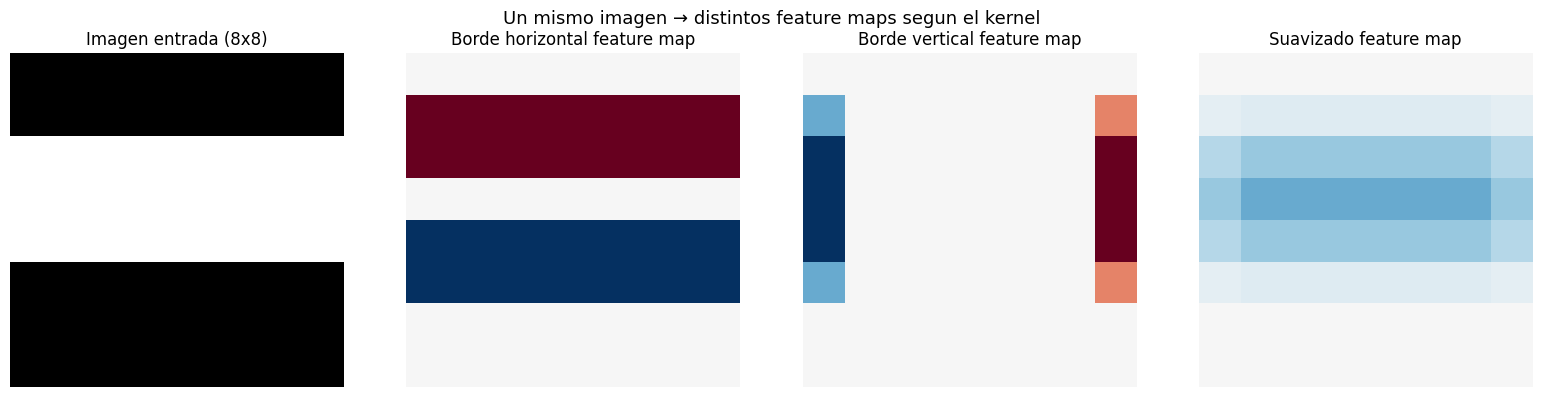

Cada filtro extrae un tipo diferente de caracteristica.
El backbone de ResNet50 tiene miles de filtros aprendidos automaticamente.


In [7]:
# Ejemplo: distintos kernels producen distintos feature maps
img_simple = torch.zeros(8, 8)
img_simple[2:5, ] = 1.0  # cuadrado blanco en el centro

kernels = {
    "Borde horizontal": torch.tensor([[ 1., 2., 1.],
                                      [ 0., 0., 0.],
                                      [-1.,-2.,-1.]]),
    "Borde vertical":   torch.tensor([[-1., 0., 1.],
                                      [-2., 0., 2.],
                                      [-1., 0., 1.]]),
    "Suavizado":        torch.tensor([[ 1., 2., 1.],
                                      [ 2., 4., 2.],
                                      [ 1., 2., 1.]]) / 16.0,
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img_simple.numpy(), cmap="gray")
axes[0].set_title("Imagen entrada (8x8)")
axes[0].axis("off")

for col, (nombre, kernel) in enumerate(kernels.items(), 1):
    conv = nn.Conv2d(1, 1, 3, padding=1, bias=False)
    with torch.no_grad():
        conv.weight = nn.Parameter(kernel.view(1, 1, 3, 3))
    out = conv(img_simple.unsqueeze(0).unsqueeze(0)).squeeze().detach().numpy()
    axes[col].imshow(out, cmap="RdBu", vmin=-2, vmax=2)
    axes[col].set_title(f"{nombre} feature map")
    axes[col].axis("off")

plt.suptitle("Un mismo imagen → distintos feature maps segun el kernel", fontsize=13)
plt.tight_layout()
plt.show()

print("Cada filtro extrae un tipo diferente de caracteristica.")
print("El backbone de ResNet50 tiene miles de filtros aprendidos automaticamente.")

## 2.1 Pooling y Activacion ReLU

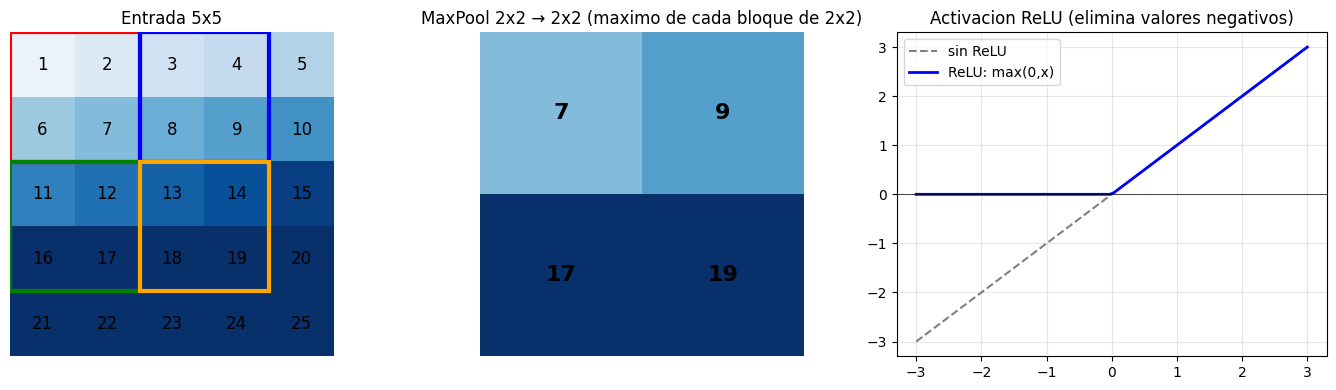

MaxPool: reduce resolucion a la mitad, conserva el valor mas alto de cada region.
ReLU: activa solo neuronas con respuesta positiva. Sin ella la red seria lineal.


In [10]:
# Visualizacion de MaxPooling y ReLU
img_pool = torch.arange(1, 26, dtype=torch.float32).view(1, 1, 5, 5)  # imagen 5x5 con valores del 1 al 25
max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
out_max = max_pool(img_pool).squeeze().detach().numpy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Entrada
ax = axes[0]
ax.imshow(img_pool.squeeze().numpy(), cmap="Blues", vmin=0, vmax=16)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f"{img_pool[0,0,i,j]:.0f}", ha="center", va="center", fontsize=12)
ax.set_title("Entrada 5x5"); ax.axis("off")
from matplotlib.patches import Rectangle
for color, (r1,r2,c1,c2) in zip(["red","blue","green","orange"],
                                  [(0,2,0,2),(0,2,2,4),(2,4,0,2),(2,4,2,4)]):
    ax.add_patch(Rectangle((c1-0.5,r1-0.5),c2-c1,r2-r1,fill=False,edgecolor=color,linewidth=3))

# MaxPool
ax = axes[1]
ax.imshow(out_max, cmap="Blues", vmin=0, vmax=16)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{out_max[i,j]:.0f}", ha="center", va="center", fontsize=16, fontweight="bold")
ax.set_title("MaxPool 2x2 → 2x2 (maximo de cada bloque de 2x2)"); ax.axis("off")

# ReLU
x = torch.linspace(-3, 3, 100)
axes[2].plot(x.numpy(), x.numpy(), "--", color="gray", label="sin ReLU")
axes[2].plot(x.numpy(), torch.relu(x).numpy(), "b-", linewidth=2, label="ReLU: max(0,x)")
axes[2].axhline(0, color="black", linewidth=0.5)
axes[2].set_title("Activacion ReLU (elimina valores negativos)")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("MaxPool: reduce resolucion a la mitad, conserva el valor mas alto de cada region.")
print("ReLU: activa solo neuronas con respuesta positiva. Sin ella la red seria lineal.")

## 2.2 Feature maps: que detecta cada capa de ResNet50

[OK] Imagen local: ./mi_mascota_1.jpeg


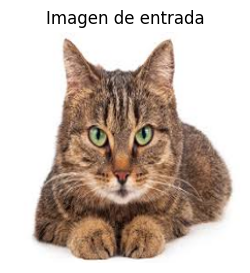

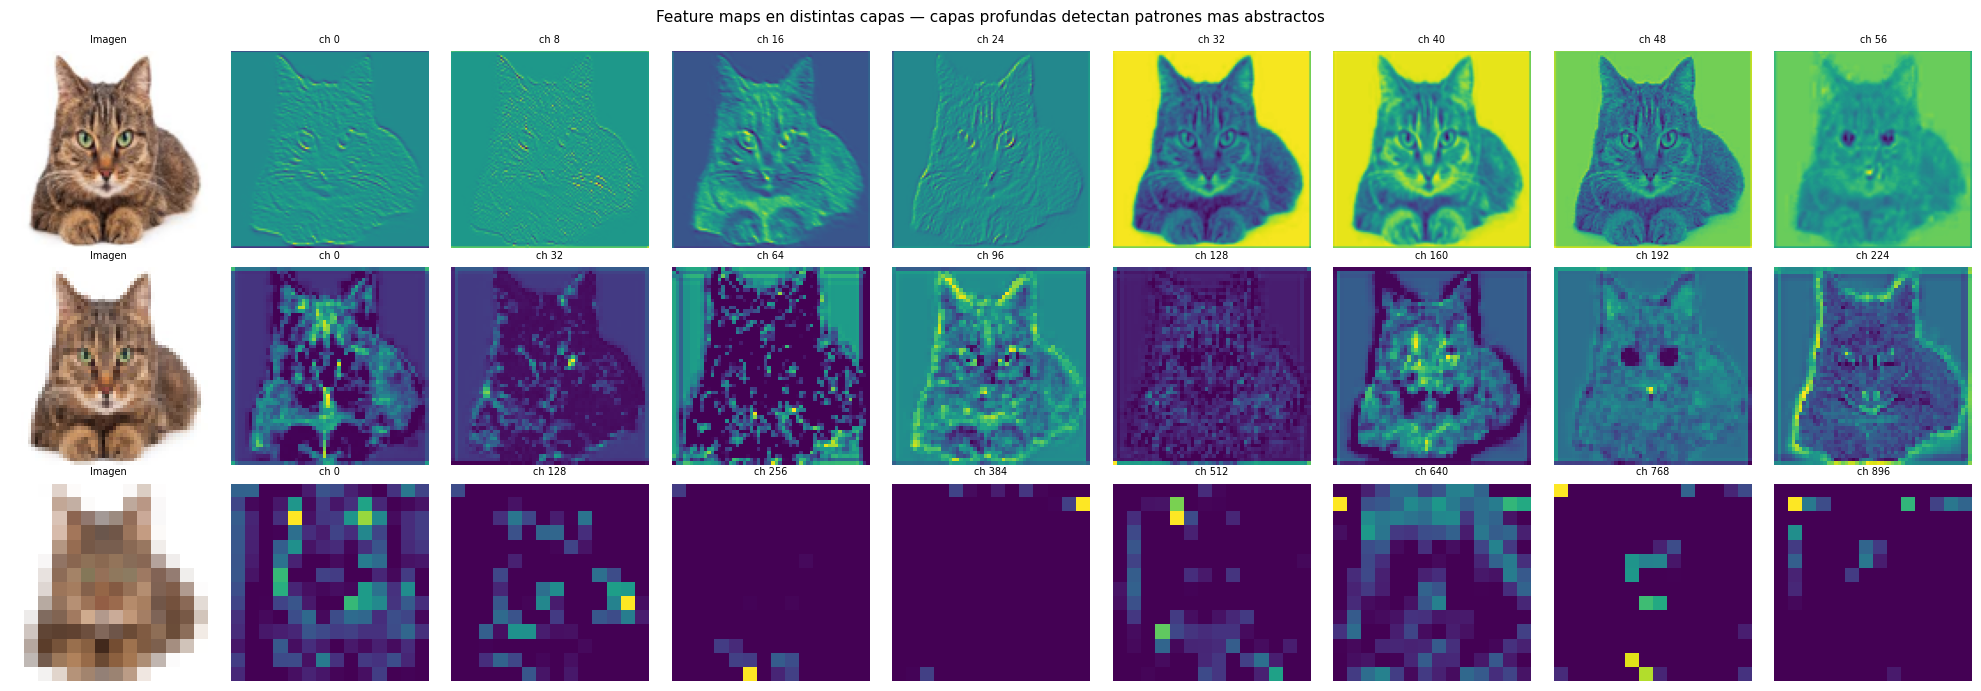

conv1 [64ch, 112x112]: shape = [64, 112, 112]
layer1 [256ch, 56x56]: shape = [256, 56, 56]
layer3 [1024ch, 14x14]: shape = [1024, 14, 14]


In [12]:
# Cargamos ResNet50 pre-entrenado
modelo_fm = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
modelo_fm.eval()

# Cargamos imagen: primero desde archivo local, luego internet, luego sintetica
def cargar_imagen(ruta_local, url_fallback):
    if os.path.exists(ruta_local):
        img = Image.open(ruta_local).convert("RGB")
        print(f"[OK] Imagen local: {ruta_local}")
        return img
    img = descargar_imagen(url_fallback)
    if img is not None:
        print(f"[OK] Imagen descargada: {url_fallback}")
        return img
    img = imagen_sintetica_escena()
    print("[--] Sin imagen local ni internet → imagen sintetica")
    return img

img_pil_demo = cargar_imagen(
    ruta_local="./mi_mascota_1.jpeg",
    url_fallback="https://upload.wikimedia.org/wikipedia/commons/2/26/YellowLabradorLooking_new.jpg"
)

# Mostramos la imagen que usamos
plt.figure(figsize=(3, 3))
plt.imshow(img_pil_demo.resize((224, 224)))
plt.title("Imagen de entrada")
plt.axis("off")
plt.show()

# Preprocesamiento
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
img_t = transform(img_pil_demo).unsqueeze(0)

# Hooks para capturar feature maps intermedios
feature_maps = {}
def make_hook(name):
    def hook(m, i, o): feature_maps[name] = o.detach()
    return hook

modelo_fm.conv1.register_forward_hook(make_hook("conv1 [64ch, 112x112]"))
modelo_fm.layer1.register_forward_hook(make_hook("layer1 [256ch, 56x56]"))
modelo_fm.layer3.register_forward_hook(make_hook("layer3 [1024ch, 14x14]"))

with torch.no_grad():
    _ = modelo_fm(img_t)

# Visualizamos 8 canales por capa
fig, axes = plt.subplots(3, 9, figsize=(20, 7))
for fila, (nombre, fmap) in enumerate(feature_maps.items()):
    fmap_np = fmap[0].numpy()
    spatial = fmap_np.shape[1]
    img_r = np.array(img_pil_demo.resize((spatial, spatial)))
    axes[fila, 0].imshow(img_r)
    axes[fila, 0].set_ylabel(nombre, fontsize=7)
    axes[fila, 0].set_title("Imagen", fontsize=7)
    axes[fila, 0].axis("off")
    step = max(1, fmap_np.shape[0] // 8)
    for col in range(8):
        ch = col * step
        fm = fmap_np[ch]
        fm_norm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)
        axes[fila, col+1].imshow(fm_norm, cmap="viridis")
        axes[fila, col+1].set_title(f"ch {ch}", fontsize=7)
        axes[fila, col+1].axis("off")

plt.suptitle("Feature maps en distintas capas — capas profundas detectan patrones mas abstractos", fontsize=11)
plt.tight_layout()
plt.show()

for nombre, fmap in feature_maps.items():
    print(f"{nombre}: shape = {list(fmap.shape[1:])}")

# 3. Datasets — Que son y tipos

Un **dataset** es una coleccion de datos etiquetados para entrenar y evaluar modelos. La calidad del dataset determina el techo de rendimiento.

## Tipos segun la tarea

| Tipo de anotacion | Que se anota | Ejemplo de dataset |
|---|---|---|
| **Clasificacion** | Una etiqueta por imagen | CIFAR-10, ImageNet |
| **Deteccion** | Bounding boxes + clase por objeto | COCO, Pascal VOC |
| **Segmentacion semantica** | Clase por pixel | Cityscapes, ADE20K |
| **Segmentacion de instancia** | Mascara individual por objeto | COCO (con masks) |
| **Keypoints** | Puntos clave (articulaciones, landmarks) | COCO-Pose, 300W |

## Datasets clasicos

| Dataset | Imagenes | Clases | Uso tipico |
|---|---|---|---|
| **MNIST** | 70K | 10 (digitos) | Clasificacion, benchmark inicial |
| **CIFAR-10** | 60K (32x32) | 10 | Clasificacion, investigacion |
| **ImageNet** | 14M | 1000 | Pre-entrenamiento de backbones |
| **COCO** | 330K | 80 | Deteccion + segmentacion |
| **Pascal VOC** | 11K | 20 | Deteccion |

## Particiones estandar

| Particion | Porcentaje tipico | Para que se usa |
|---|---|---|
| **Train** | 70-80% | Entrenar el modelo |
| **Validation** | 10-15% | Ajustar hiperparametros, monitorear |
| **Test** | 10-15% | Evaluacion final (no tocar hasta el final) |

In [13]:
# CIFAR-10: dataset de clasificacion con 10 clases
# 60.000 imagenes 32x32 pixels a color

transform_cifar = T.Compose([T.ToTensor()])

print("Descargando CIFAR-10...")
cifar10 = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_cifar)

CLASES = ["avion", "auto", "pajaro", "gato", "ciervo",
           "perro", "rana", "caballo", "barco", "camion"]

print(f"Total imagenes (train): {len(cifar10)}")
print(f"Tamano de imagen: {cifar10[0][0].shape}  (canales × alto × ancho)")
print(f"Clases: {CLASES}")


Descargando CIFAR-10...


100.0%


Total imagenes (train): 50000
Tamano de imagen: torch.Size([3, 32, 32])  (canales × alto × ancho)
Clases: ['avion', 'auto', 'pajaro', 'gato', 'ciervo', 'perro', 'rana', 'caballo', 'barco', 'camion']


/home/alfredo-sanz/Documentos/GitHub/IA5.2_CV/u_1/practica/red_n/venv-ia/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


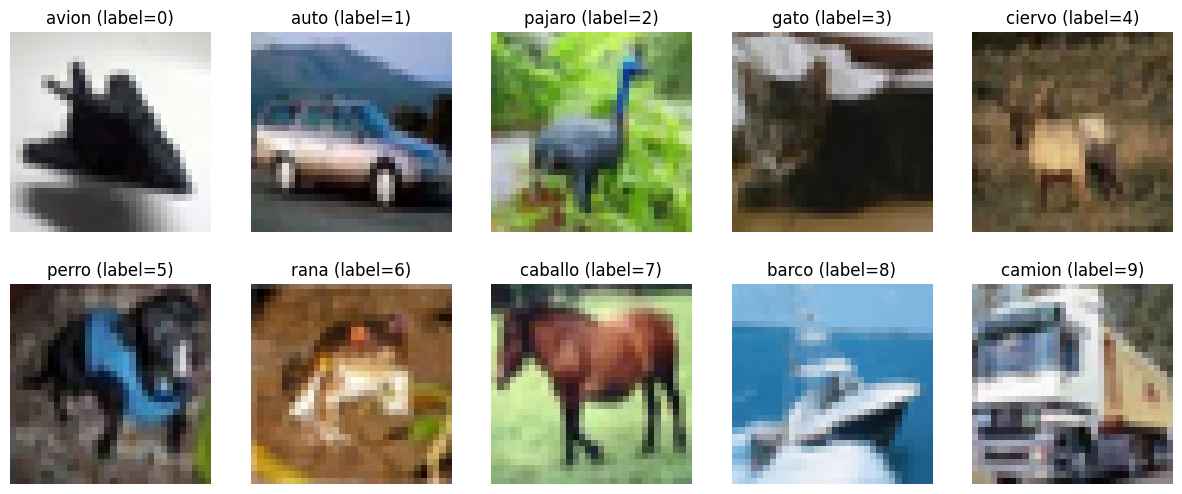

In [14]:
# Imprimir una imagen de cada clase
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    idx = next(j for j, (_, label) in enumerate(cifar10) if label == i)
    img, label = cifar10[idx]
    axes[i//5, i%5].imshow(img.permute(1, 2, 0))
    axes[i//5, i%5].set_title(f"{CLASES[label]} (label={label})")
    axes[i//5, i%5].axis("off") 

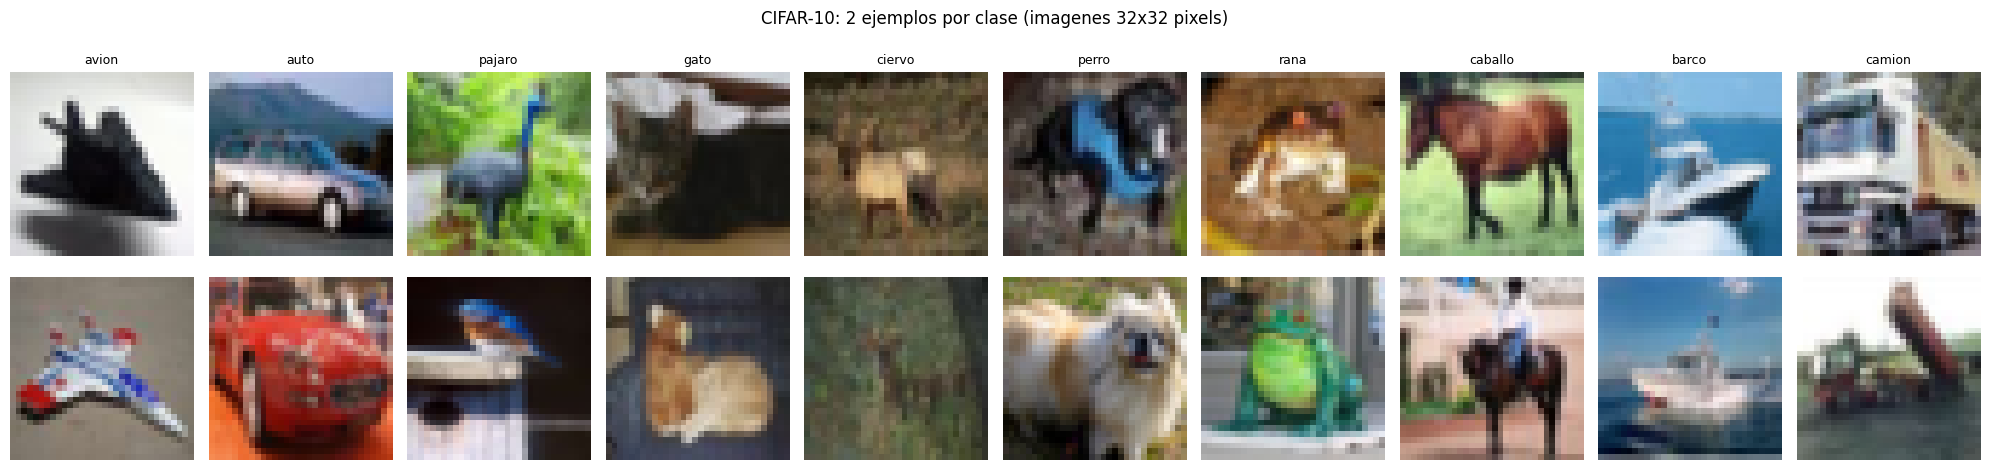

Distribucion de clases (train):
     avion:  5000 #########################
      auto:  5000 #########################
    pajaro:  5000 #########################
      gato:  5000 #########################
    ciervo:  5000 #########################
     perro:  5000 #########################
      rana:  5000 #########################
   caballo:  5000 #########################
     barco:  5000 #########################
    camion:  5000 #########################


In [15]:

# Buscamos 2 ejemplos por clase
indices_por_clase = {i: [] for i in range(10)}
for idx, (img, label) in enumerate(cifar10):
    if len(indices_por_clase[label]) < 2:
        indices_por_clase[label].append(idx)
    if all(len(v) >= 2 for v in indices_por_clase.values()):
        break

fig, axes = plt.subplots(2, 10, figsize=(20, 5))
for col, (clase_id, idxs) in enumerate(indices_por_clase.items()):
    for fila, idx in enumerate(idxs[:2]):
        img, _ = cifar10[idx]
        axes[fila, col].imshow(img.permute(1, 2, 0).numpy())
        if fila == 0:
            axes[fila, col].set_title(CLASES[clase_id], fontsize=9)
        axes[fila, col].axis("off")

plt.suptitle("CIFAR-10: 2 ejemplos por clase (imagenes 32x32 pixels)", fontsize=12)
plt.tight_layout()
plt.show()

# Distribucion de clases
conteo = [0] * 10
for _, label in cifar10:
    conteo[label] += 1
print("Distribucion de clases (train):")
for clase, count in zip(CLASES, conteo):
    barra = "#" * (count // 200)
    print(f"  {clase:>8}: {count:5d} {barra}")

# 4. ResNet50 Pre-entrenado — Ejemplo Practico de Clasificacion

ResNet50 entrenado en **ImageNet** puede reconocer **1000 categorias** de objetos comunes.

**Preprocesamiento obligatorio para ImageNet:**
```python
mean = [0.485, 0.456, 0.406]   # media de ImageNet por canal RGB
std  = [0.229, 0.224, 0.225]   # desvio estandar de ImageNet
```
El modelo ESPERA entradas con esta normalizacion. Si la normalizacion es incorrecta, las predicciones seran basura aunque la imagen sea correcta.

**Modo evaluacion**: siempre llamar `model.eval()` antes de inferencia. Esto:
- Desactiva Dropout
- Configura BatchNorm en modo estadistico (usa parametros aprendidos, no estadisticas del batch actual)

In [67]:
# Cargamos ResNet50 pre-entrenado
modelo_cls = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
modelo_cls.eval()

# Etiquetas de ImageNet (1000 clases)
try:
    import ssl as _ssl
    url_labels = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
    _ctx = _ssl.create_default_context()
    _ctx.check_hostname = False
    _ctx.verify_mode = _ssl.CERT_NONE
    with urllib.request.urlopen(url_labels, timeout=8, context=_ctx) as resp:
        etiquetas = [line.strip() for line in resp.read().decode("utf-8").splitlines()]
    print(f"Etiquetas cargadas: {len(etiquetas)} clases — primeras 5: {etiquetas[:5]}")
except Exception as e:
    etiquetas = [f"clase_{i}" for i in range(1000)]
    print(f"No se pudo descargar etiquetas ({e}) → usando nombres genericos")

# Preprocesamiento estandar de ImageNet
transform_imagenet = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

# Imagenes: local → internet → sintetica
imagenes_cfg = [
    ("./data/YellowLabradorLooking_new.jpg",
     "https://upload.wikimedia.org/wikipedia/commons/2/26/YellowLabradorLooking_new.jpg",
     "perro"),
    ("./data/cute_cat.jpg",
     "https://upload.wikimedia.org/wikipedia/commons/thumb/4/43/Cute_cat.jpg/320px-Cute_cat.jpg",
     "gato"),
]

imagenes_pil = []
nombres = []
for ruta_local, url_fallback, nombre in imagenes_cfg:
    img = cargar_imagen(ruta_local, url_fallback)
    imagenes_pil.append(img)
    nombres.append(nombre)

# Clasificamos y mostramos Top-5
print("\n=== Predicciones Top-5 ===")
for img_pil, nombre in zip(imagenes_pil, nombres):
    img_t = transform_imagenet(img_pil).unsqueeze(0)
    with torch.no_grad():
        probs = torch.softmax(modelo_cls(img_t), dim=1)
    top5_probs, top5_idx = torch.topk(probs, k=5)
    print(f"\n[{nombre}]")
    for prob, idx in zip(top5_probs[0], top5_idx[0]):
        print(f"  {prob.item()*100:5.1f}%  {etiquetas[idx.item()]}")

Etiquetas cargadas: 1000 clases — primeras 5: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']
[OK] Imagen local: ./data/YellowLabradorLooking_new.jpg
[OK] Imagen local: ./data/cute_cat.jpg

=== Predicciones Top-5 ===

[perro]
   52.4%  Labrador retriever
    7.2%  Chesapeake Bay retriever
    5.1%  golden retriever
    3.7%  dingo
    2.7%  bloodhound

[gato]
   57.4%  tiger cat
   22.4%  tabby
    7.2%  lynx
    3.2%  Egyptian cat
    3.1%  Persian cat


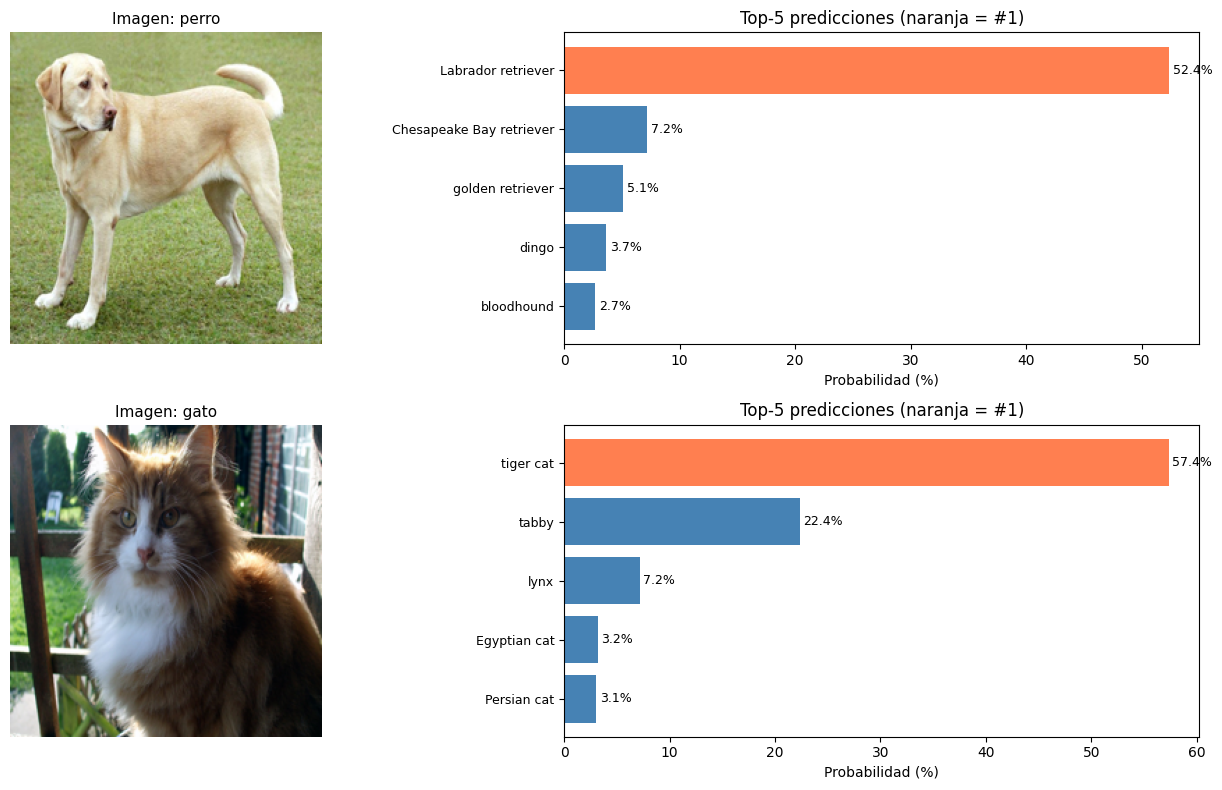

In [68]:
# Visualizamos predicciones con graficos de barras
fig, axes = plt.subplots(len(imagenes_pil), 2, figsize=(14, 4 * len(imagenes_pil)))
if len(imagenes_pil) == 1:
    axes = [axes]

for fila, (img_pil, nombre) in enumerate(zip(imagenes_pil, nombres)):
    img_t = transform_imagenet(img_pil).unsqueeze(0)
    with torch.no_grad():
        probs = torch.softmax(modelo_cls(img_t), dim=1)
    top5_probs, top5_idx = torch.topk(probs, k=5)

    axes[fila][0].imshow(img_pil.resize((224, 224)))
    axes[fila][0].set_title(f"Imagen: {nombre}", fontsize=11)
    axes[fila][0].axis("off")

    top5_etiq = [etiquetas[i.item()][:25] for i in top5_idx[0]]
    top5_vals = [p.item() * 100 for p in top5_probs[0]]
    colors = ["coral"] + ["steelblue"] * 4

    axes[fila][1].barh(range(5), top5_vals[::-1],
                       color=colors[::-1])
    axes[fila][1].set_yticks(range(5))
    axes[fila][1].set_yticklabels(top5_etiq[::-1], fontsize=9)
    axes[fila][1].set_xlabel("Probabilidad (%)")
    axes[fila][1].set_title("Top-5 predicciones (naranja = #1)")
    for i, val in enumerate(top5_vals[::-1]):
        axes[fila][1].text(val + 0.3, i, f"{val:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

---
# Ejercicios

## Ejercicio 1: Explorar las capas de ResNet50

Usando `named_modules()`, recorrer el modelo `modelo_cls` y listar todas las capas `nn.Conv2d` con:
- Nombre de la capa
- Canales de entrada (`in_channels`)
- Canales de salida (`out_channels`)
- Tamaño de kernel (`kernel_size`)

Responder: ¿Cuántas capas Conv2d tiene ResNet50 en total? ¿Cómo evoluciona el número de canales a lo largo de la red?

In [69]:
# Ejercicio 1: Completar aqui

# 1-2. Listar capas Conv2d con sus parametros
# for nombre, modulo in modelo_cls.named_modules():
#     if isinstance(modulo, nn.Conv2d):
#         # TODO: imprimir nombre, in_channels, out_channels, kernel_size

# 3. Contar total de capas Conv2d
# n_conv = sum(1 for _, m in modelo_cls.named_modules() if isinstance(m, nn.Conv2d))
# print(f"Total Conv2d: {n_conv}")

## Ejercicio 2: Filtros aprendidos vs filtros aleatorios

En la Seccion 2 vimos kernels diseñados a mano. Ahora comparamos los filtros de dos versiones de ResNet50:
- `modelo_cls`: pre-entrenado en ImageNet (Seccion 4)
- `modelo`: sin pesos, inicializado aleatoriamente (Seccion 1)

**Pasos:**
1. Acceder a los filtros de `conv1` en ambos modelos: `.conv1.weight.data` — shape `[64, 3, 7, 7]`
2. Completar la normalizacion para poder visualizar cada filtro como imagen
3. Mostrar los 64 filtros de cada modelo en una grilla 8×8

**Pista de normalizacion:** `f_norm = (f - f.min()) / (f.max() - f.min() + 1e-8)`

Responder: ¿Que diferencia ves entre los filtros pre-entrenados y los aleatorios? ¿Por que crees que es asi?

In [ ]:
def mostrar_filtros(modelo, titulo):
    filtros = modelo.conv1.weight.data  # [64, 3, 7, 7]
    fig, axes = plt.subplots(8, 8, figsize=(12, 12))
    for i, ax in enumerate(axes.flat):
        f = filtros[i].permute(1, 2, 0).numpy()  # [7, 7, 3]
        f_norm = ...  # TODO: normalizar f al rango [0, 1]
        ax.imshow(f_norm)
        ax.axis("off")
    plt.suptitle(titulo, fontsize=13)
    plt.tight_layout()
    plt.show()

# TODO: llamar mostrar_filtros para modelo_cls y para modelo
# mostrar_filtros(modelo_cls, "...")
# mostrar_filtros(modelo,     "...")

## Ejercicio 3: Efecto del preprocesamiento en las predicciones

El preprocesamiento correcto es **critico** para que ResNet50 funcione. En este ejercicio comparamos tres variantes.

**Pasos:**
1. Usar una de las imagenes de `imagenes_pil`.
2. Crear 3 transformaciones:
   - `prep_correcto`: estandar ImageNet (Resize 256 → CenterCrop 224 → ToTensor → Normalize con `[0.485,0.456,0.406]` y `[0.229,0.224,0.225]`)
   - `prep_sin_norm`: igual pero sin `Normalize`
   - `prep_norm_mal`: `Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])` (incorrecto)
3. Para cada una, clasificar con `modelo_cls` y mostrar las Top-3 predicciones + probabilidades + rango del tensor.
4. Responder en markdown: ¿Como afecta la normalizacion incorrecta a las predicciones? ¿Por que?

In [73]:
# Ejercicio 3: Completar aqui

preprocs = {
    "Correcto (ImageNet)": None,       # TODO: completar
    "Sin normalizacion":   None,       # TODO: completar
    "Norm incorrecta":     None,       # TODO: completar
}

# Para cada preprocesamiento:
# img_t = preprocesamiento(imagenes_pil[0]).unsqueeze(0)
# with torch.no_grad():
#     probs = torch.softmax(modelo_cls(img_t), dim=1)
# top3_probs, top3_idx = torch.topk(probs, k=3)
# Mostrar top-3 y rango del tensor